In [113]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [114]:
df = pd.read_csv("train.csv")
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [115]:
df.drop("id", axis=1, inplace=True)
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  object 
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 45.8+ MB


In [117]:
df.isnull().sum()

Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

<Axes: >

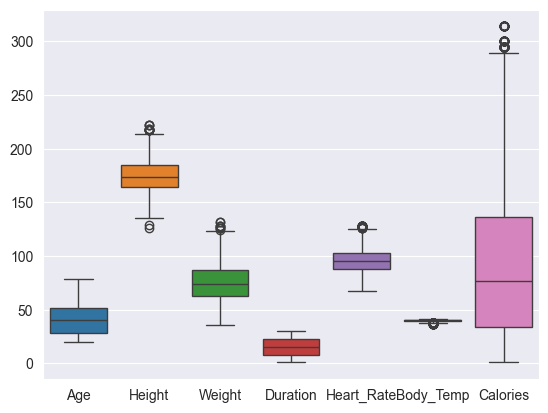

In [118]:
sns.boxplot(df)

In [119]:
df["Sex"].value_counts()

Sex
female    375721
male      374279
Name: count, dtype: int64

In [120]:
df.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories'],
      dtype='object')

<Axes: >

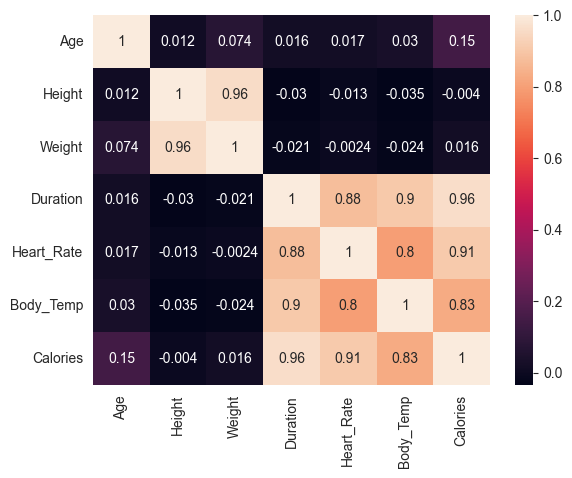

In [121]:
numerical_columns = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories']
sns.heatmap(df[numerical_columns].corr(), annot=True)

Ознаки корелюють між собою, тому краще не використовувати звичайну лінійну регресію.

In [122]:
df.groupby("Sex")["Calories"].mean()

Sex
female    87.534761
male      89.033683
Name: Calories, dtype: float64

In [123]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [124]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [125]:
X = df.drop("Calories", axis=1)
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    loss_function='RMSE',
    depth=5,
    verbose=False,
    random_seed=42
)

In [127]:
cat_list = ["Sex"]

In [128]:
model.fit(
    X_train, y_train,
    cat_features=cat_list,
    eval_set=(X_test, y_test)
)

model.fit(X_train, np.log1p(y_train),
          cat_features=cat_list,
    eval_set=(X_test, y_test)
)

preds_log = model.predict(X_test)
test_predictions = np.expm1(preds_log)
test_predictions = np.maximum(0, test_predictions)

In [129]:
prediction = model.predict(X_test)

In [130]:
r2_score(prediction, y_test)

-11743.398656213583

In [131]:
mean_absolute_percentage_error(y_test, prediction)

0.9110189859605495

In [132]:
test_df = pd.read_csv('test.csv')

test_ids = test_df['id']
X_test_final = test_df.drop(['id'], axis=1)

preds_log = model.predict(X_test_final)

test_predictions = np.expm1(preds_log)

test_predictions = np.maximum(0, test_predictions)

In [133]:
submission = pd.read_csv('sample_submission.csv')

submission['Calories'] = test_predictions

submission.to_csv('my_submission.csv', index=False)

In [146]:
data = pd.read_csv("my_submission.csv")